
<center><font size=10>Prompt Optimization and Evaluation</center></font>


# Problem Statement

## Business Context

NovaTech is a  mid-sized consumer electronics company with products such as smartphones, laptops, headphones, smartwatches.

They operate in the highly competitive markets of US, Canada, and UK, selling a portfolio of 34 active SKUs (including smartphones, laptops, headphones, and smartwatches).

In the current product development cycle, the product team consisting of six Product Managers (PMs) receives and processes over 8000 customer reviews per week (overall), which is read and categorized manually, which amounts to 306 hours per quarter.

However, the core **problem** is that the team is allocated only 160 hrs/quarter.

As a result, the following are the **observed AI failures** (identified by an internal audit over 2 quarters):
- **Hallucinations:** Summaries contained fabricated feature references
- **Positivity Bias**: 41% were net-positive in tone even when source reviews were predominantly negative
- **Real-World Loss**: Two product improvement decisions (such as the X12 headphones EQ, W4 smartwatch battery UI) were based on misleading summaries - both received worse post-launch reviews

The current AI infrastructure just generated AI summaries without any evaluation strategies in place.

The approach lacks a **grounding mechanism** (to cite sources), prevents short "noise" from drowning out technical "signal", and an **accuracy checkpoint** (to catch errors before they reach the PM).

> *Figures above are illustrative of patterns at mid-sized companies; they are not NovaTech-specific operational data.*

## Objective

Within the next six months, NovaTech will implement a verified Grounded Feedback Loop - a Phase 1 automated pipeline
that serves the product team by replacing manual review skimming with structured, evaluated, and confidence-gated
summaries.

- **Grounded Summarisation:** Every product summary will be generated strictly from source review content, with
explicit guardrails preventing fabrication - directly addressing the 23% hallucination rate and 41% positivity bias
observed in the failed pilot.

- **Automated Quality Evaluation:** Each generated summary will be scored across quality dimensions -
faithfulness, balance, coverage, structure, hallucination detection, and confidence - ensuring no output
reaches a Product Manager without passing an accuracy checkpoint.

- **Self-Improving Prompt Optimisation:** Where evaluation scores fall below threshold, the system will automatically
generate an improved prompt and re-summarise, reducing the need for manual prompt tuning over time.

- **Confidence-Based Routing:** Outputs will be routed based on confidence score - high-confidence summaries sent
directly to the PM, medium-confidence flagged for awareness, and low-confidence held for human review before any
product decision is made.

## Data Description

**Dataset A - gold_reviews.csv**

This dataset contains customer reviews for NovaTech's core consumer electronics portfolio. It has 4 products across 4 categories - Smartphones, Laptops, Headphones, and Smartwatches. Each row represents one product and contains the following fields: product_id, product_name, category, total_reviews, avg_rating, and reviews_text.


**Dataset B - test_reviews.csv**

This dataset serves as the generalisation test set used in Phase 8 of the workflow. It covers 5 products across 5 different categories - Outdoor Equipment, PC Accessories, Home and Sleep, and Personal Transport . The schema is identical to Dataset A. This dataset a suitable cross-domain validation set for testing whether the optimised prompt generalises beyond the products it was tuned on.


# Solution Workflow

We'll follow a structured pipeline that will be used to create the entire workflow using a evaluation-driven approach.

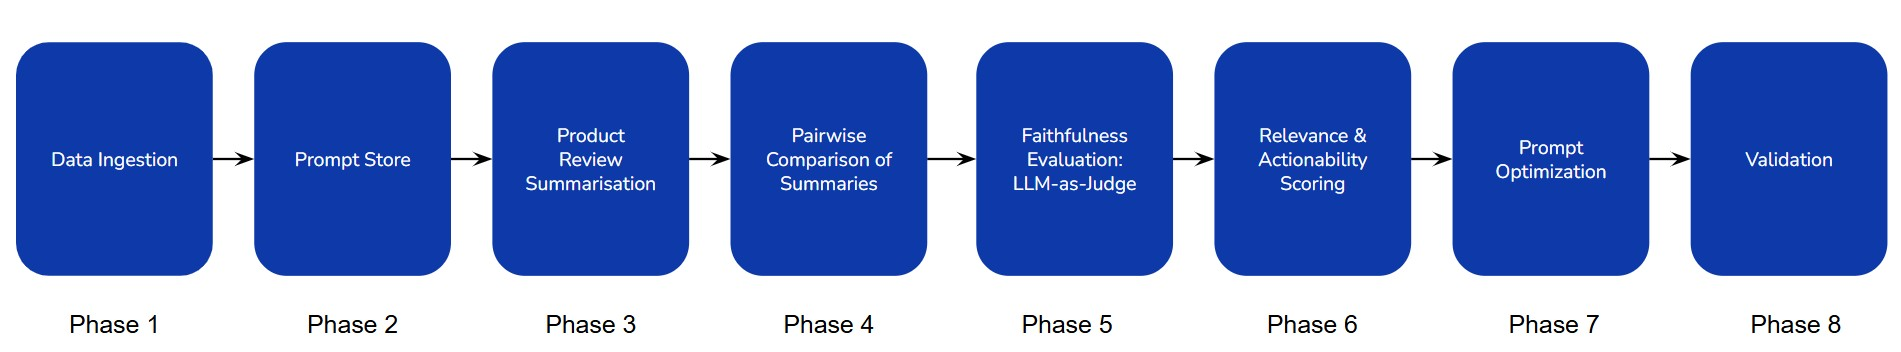

The pipeline is structured around a simple idea: each phase catches a specific failure mode whereas the original NovaTech system produced summaries and stopped. This one produces summaries with verdicts.

**Phase 1 - Data Ingestion**

This stage parses CSVs into per-product items.

**Phase 2 - Configuration Store**

This stage tags every output with prompt_version and a YAML describing the prompt's intent and known weaknesses. Versioning prompts is important in a production setting, when a PM asks "Why did this summary change last month?" without versioning, you can't answer.

**Phase 3 - Summarisation**

This stage produces summaries, this is the actual generation step. Structured JSON output so downstream judges can score specific fields, at temperature 0.1 so outputs are stable. Everything after this is evaluation of this output.

**Phase 4 - Pairwise Comparison**

Phase 4 asks **is it stable?**

This stage runs the prompt twice and compares both outputs. It tests whether the prompt is stable - whether running the pipeline tomorrow would produce a materially different summary.

**Phase 5 - Faithfulness, Balance and Hallucination Scoring**

Phase 5 asks **is it truthful?**

This is the central phase. A single LLM judge independently reads the source reviews and scores the summary for faithfulness and balance on a 0–1 scale, emitting a binary hallucination flag. This is the grounding mechanism the original pipeline lacked, what catches the hallucination rate before it reaches a PM.

**Phase 6 - Relevance, Clarity and Actionability Scoring**

Phase 6 asks **is it useful?**

Phase 5 catches wrong summaries, whereas Phase 6 catches useless ones. A summary can be 100% faithful and still too vague to act on ("customers had mixed feelings about battery"). Different failure mode, different evaluation, this phase outputs an approve/review/reject recommendation.

**Phase 7 - Prompt Optimisation (GEPA)**

Phase 7 asks **can the prompt be improved?**

Phases 3–6 measure how good the prompt is. This phase uses that measurement to improve the prompt automatically, producing an optimised prompt that generalises across NovaTech's diverse product categories.

**Phase 8 - Evaluate Optimised Prompt on Test Dataset**

Phase 8 asks **does it hold up on unseen products?**

Runs the full pipeline Phases 4 (pairwise), 5 (faithfulness judge), 6 (relevance & actionability), and per-instance GEPA scoring - on `test_dataset` using the GEPA-optimised prompt. Each product receives a confidence score (0–100) and results are exported to CSV.

# Installing and Importing Necessary Libraries and Dependencies

In [1]:
# Install the Python libraries used in this notebook.
!pip install -q \
pandas==3.0.3 \
numpy==2.4.4 \
matplotlib==3.10.9 \
openai==2.36.0 \
optuna==4.8.0 \
dspy==3.2.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.0/331.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.5/146.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel, and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [1]:
# Hiding Warnings
import warnings
warnings.filterwarnings('ignore')

# Standard library imports
import os, json, re, io
import pandas as pd
import time
from datetime import datetime

# OpenAI Python client - used by the llm_response() helper for the
# faithfulness, relevance, and pairwise judges that drive Phases 4-6.
from openai import OpenAI

# DSPy - signatures, modules, predictors, and the GEPA optimiser (Phase 7).
import dspy

# Pandas display configuration for wider tables.
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

### OpenAI API Calling



In [2]:
# Load the `config.json` file and extract values

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    if config.get("API_KEY"):
        os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
        # Showing only a partial key using slicing for security/privacy
        print(f"API Key loaded successfully :  {os.environ['OPENAI_API_KEY'][:15]}...")

    if config.get("OPENAI_API_BASE"):
        os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url
        print(f"API Base URL loaded successfully :  {os.environ['OPENAI_BASE_URL']}")

# Initialize OpenAI client
client = OpenAI()

API Key loaded successfully :  gl-U2FsdGVkX19g...
API Base URL loaded successfully :  https://aibe.mygreatlearning.com/openai/v1


Converts the LLM output into a valid Python dictionary by removing markdown formatting and extracting the JSON content.


In [3]:
# ──  LLM JSON response ───────────────────────────────────────────
def parse_llm_json(raw: str) -> dict:
    """Strip markdown fences and parse the first JSON object found."""
    # Use regex to remove common markdown code block markers (e.g., ```json)
    cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")

    # Locate the first '{' and last '}' to isolate the JSON object if there is extra text
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if match:
        cleaned = match.group(0)

    # Convert the cleaned string into a Python dictionary
    return json.loads(cleaned)

Sends a user and system prompt to the LLM model and returns the generated text response from the assistant.


In [4]:
# ──  OpenAI Chat Completions ───────────────────────────────────────────────────
def llm_response(system: str, user: str, temperature: float = 0.1) -> str:
    """Single-turn chat completion. Returns the assistant content string."""
    # Create a completion using the initialized client and global MODEL variable
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=temperature,
        messages=[
            {"role": "system", "content": system}, # Sets the AI persona/rules
            {"role": "user",   "content": user},   # The specific user prompt
        ],
    )
    # Extract and return the text content from the first response choice
    return response.choices[0].message.content

In [5]:
## Test the ChatCompletions API
llm_response("You're a helpful AI assistant", "Capital of France is")

'The capital of France is Paris.'

# Naive Workflow Implementation

This section reproduces NovaTech's existing workflow as it ran in production

In [6]:
gold_dataset_path= "/content/gold_reviews.csv"
test_dataset_path = "/content/test_reviews.csv"

In [7]:
gold_dataset = pd.read_csv(gold_dataset_path)
test_dataset = pd.read_csv(test_dataset_path)

In [8]:
BASE_SYSTEM_PROMPT = "You are a helpful assistant that summarises customer product reviews."

In [9]:
def summarise_naive(item: dict) -> str:
    user_prompt = f"""Summarise these customer reviews for the product team.
                      Product : {item['product_name']}
                      Reviews : {item['reviews_text']}
                      Provide a summary with key positives, complaints, and feature requests."""

    return llm_response(BASE_SYSTEM_PROMPT, user_prompt)

In [10]:
# Instead of building a dict, iterating a DataFrame, and tracking i manually:
def generate_and_display_summaries(df):
    for i, item in enumerate(df.to_dict(orient="records"), 1):
        summary = summarise_naive(item)
        print(f"# {i}")
        print(f"Product: {item['product_name']}")
        print(f"Summary: {summary}")
        print("=" * 50)

In [11]:
generate_and_display_summaries(gold_dataset)

# 1
Product: NovaTech X12 Smartphone
Summary: **Summary of Customer Reviews for NovaTech X12 Smartphone**

**Key Positives:**
- **Battery Life:** Many users praised the impressive battery life, with some reporting it lasts up to two days with normal use.
- **Camera Quality:** The camera is noted for taking stunning photos in daylight, with some users highlighting the AI photo processing and cinema-quality video recording.
- **Display:** The vibrant colors and smooth 120Hz refresh rate of the display received positive feedback, enhancing the gaming experience.
- **Performance:** Users appreciated the ultra-smooth performance for everyday tasks and the instant face unlock feature.
- **Design:** The slim design is perceived as premium, contributing to overall user satisfaction.

**Complaints:**
- **Fingerprint Sensor:** Several users reported that the fingerprint sensor is slow to respond or unreliable.
- **Heating Issues:** Some users experienced the phone getting hot during extended use

**Observations**

- The architecture is simple - the code reads the product reviews, calls the model, and writes the results to a CSV, which is then handed to the PM.

- It's easy to notice why this workflow is not performant - there're no prompt version tags, no second run, no evaluation, no relevance check, no optimisation, no held-out validation, no confidence score.
the workflow performs a simple summary generation.

- The summaries read fluently - however, the failure mode (hallucination, bad product reviews) is invisible at the output, which is exactly why an evaluation layer is needed.

The following workflow will implement the updated workflow for solving NovaTech's objective.

# Evaluation-Driven Workflow

**NOTE**: Since LLM-generated outputs are inherently probabilistic and non-deterministic, slight variations in evaluation metrics are expected across runs.

## Phase 1 - Data Ingestion

The datasets were loaded during the initial setup. We will proceed using the existing `gold_dataset` and `test_dataset` DataFrames.

In [12]:
# gold_dataset_path= "/content/gold_reviews.csv"
# test_dataset_path = "/content/test_reviews.csv"

In [13]:
# gold_dataset = pd.read_csv(gold_dataset_path)
# test_dataset = pd.read_csv(test_dataset_path)

In [14]:
gold_dataset.head()

,product_id,product_name,category,total_reviews,avg_rating,test_case_type,edge_case_description,reviews_text
0,P001,NovaTech X12 Smartphone,Smartphones,8,3.8,"BASELINE — mixed sentiment, medium rating",Normal mixed product. Baseline test case.,Review 1 (5 stars): Battery life on this X12 is incredible. I use it heavily...
1,P002,NovaTech ProBook 15,Laptops,7,3.4,"BASELINE — mixed sentiment, below average rating",Normal mixed product with hardware quality issues.,"Review 1 (4 stars): Keyboard is the best I have typed on in years - tactile,..."
2,P003,NovaTech SoundPods Elite,Headphones,9,4.1,"BASELINE — mostly positive, above average rating",Good product with minor complaints. Tests whether AI avoids over-positivity.,Review 1 (5 stars): The noise cancellation is phenomenal. I wear these on my...
3,P004,NovaTech PowerBand Smartwatch,Smartwatches,6,5.0,"EDGE CASE — all 5-star reviews, unanimously positive",Tests whether AI correctly summarises a genuinely excellent product without ...,Review 1 (5 stars): This smartwatch is flawless. The health tracking is incr...
4,P005,NovaTech AirCooler Mini,Home Appliances,7,1.3,"EDGE CASE — almost all 1-star reviews, product failure",Tests whether AI honestly reflects overwhelmingly negative sentiment without...,Review 1 (1 star): Complete waste of money. Stopped working after 3 days. Ma...


## Phase 2 - Configuration Store



Before generating any summaries, we pin down **which** prompt is being used and tag every record with that version, stored directly as a column in the DataFrame.

This means every product row carries its own prompt snapshot in memory. When a score changes between runs, you can tell immediately whether the prompt changed or the data did, the version tag travels with the record.

The prompt is stored as YAML alongside its known weaknesses. For this notebook we attach it directly to the DataFrame; in a production setup this would live in a separate config file or prompt registry.

In [15]:
# ── Phase 2: Prompt Versioning & Configuration ────────────────────────────────
# We pin the prompt version to 'v1.0' and store the design intent/weaknesses.
# This ensures every summary generated is traceable to a specific prompt state.

ACTIVE_PROMPT_VERSION = "v1.0"

PROMPT_V1_YAML = """
version: v1.0
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  Generate structured product summaries from raw customer reviews.
  Enforce honest balance between praise and complaints.
  Return strict JSON with no hallucinated claims.
known_weaknesses:
  - May overgeneralise from small sample of reviews
  - 'feature_requests' field occasionally empty even when present in reviews
  - No explicit instruction to cite evidence for claims
"""

In [16]:
gold_dataset['active_prompt_version'] = ACTIVE_PROMPT_VERSION
gold_dataset['prompt_v1_yaml'] = PROMPT_V1_YAML

## Phase 3 - Summarisation

Generate one structured summary per product using the v1.0 prompt at temperature 0.1. Unlike the naive version, this prompt enforces:
- Claims grounded in the source reviews
- Honest sentiment balance
- A strict JSON schema with positives, complaints, feature requests, and overall sentiment

The structured output is what makes every downstream phase pairwise comparison, judges, relevance scoring possible.

In [17]:
# Define the system persona for the LLM to act as a specialized analyst.
# This sets the behavioral constraints and operational rules for the generation.
SUMMARISE_SYSTEM_PROMPT = """You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded product summaries from customer reviews.
Rules:
1. ONLY include claims that are explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so.
3. Never invent product features, fixes, or customer opinions not present in the source.
4. Return ONLY a valid JSON object. No preamble, no markdown fences."""

In [18]:
def build_summary_prompt(item: dict) -> str:
    """Constructs the user-facing prompt with product metadata and review text."""
    return f"""You are summarising customer reviews for NovaTech's product team.

--- NOW SUMMARISE THE FOLLOWING PRODUCT ---
Product Name  : {item['product_name']}
Category      : {item['category']}
Total Reviews : {item['total_reviews']}
Average Rating: {item['avg_rating']} / 5

Reviews Text:
{item['reviews_text']}

Return a JSON object with exactly these keys:
{{
  "summary": "2-3 sentence balanced summary grounded in the reviews above",
  "top_positives": ["list of 2-4 specific positives mentioned in reviews"],
  "top_complaints": ["list of 2-4 specific complaints mentioned in reviews"],
  "feature_requests": ["list of improvements customers explicitly asked for"],
  "overall_sentiment": "one of: Positive / Mixed (leaning positive) / Mixed / Mixed (leaning negative) / Negative"
}}   """

In [19]:
def summarise_item(item: dict,SYSTEM_PROMPT,ACTIVE_PROMPT_VERSION) -> dict:
    """Generates a single grounded summary for a product item, parses the JSON, and merges it back."""
    # 1. Call the LLM using the chat helper function defined in Phase 1
    raw    = llm_response(SYSTEM_PROMPT, build_summary_prompt(item), temperature=0.1)

    # 2. Parse the raw string response into a Python dictionary
    parsed = parse_llm_json(raw)

    # 3. Return the original product item dictionary updated with the new summary fields
    return {
        **item,
        "summary"          : parsed.get("summary",           ""),
        "top_positives"    : parsed.get("top_positives",     []),
        "top_complaints"   : parsed.get("top_complaints",    []),
        "feature_requests" : parsed.get("feature_requests",  []),
        "overall_sentiment": parsed.get("overall_sentiment", ""),
        "prompt_version"   : parsed.get("prompt_version",    ACTIVE_PROMPT_VERSION),
        "_raw_summary"     : raw,
    }

In [20]:
# Execution: Generate summaries for all records in the primary dataset
print("Generating summaries...")
summarised_items = [summarise_item(item,SUMMARISE_SYSTEM_PROMPT,ACTIVE_PROMPT_VERSION) for item in gold_dataset.to_dict(orient='records')]

# Visualization: Print the results in a readable format for quick inspection
for item in summarised_items:
    print(f"{'='*70}")
    print(f"{item['product_name']} ({item['product_id']})")
    print(f"Summary   : {item['summary']}")
    print(f"Sentiment : {item['overall_sentiment']}")
    print(f"Complaints: {item['top_complaints']}")

Generating summaries...
NovaTech X12 Smartphone (P001)
Summary   : The NovaTech X12 Smartphone has received a mix of positive and negative feedback from users. While many appreciate its impressive battery life, vibrant display, and overall performance, several customers have reported issues with the fingerprint sensor, occasional software crashes, and the lack of a charging brick in the box.
Sentiment : Mixed (leaning positive)
Complaints: ['Fingerprint sensor is slow and unreliable', 'Phone froze and required hard resets', 'Display has a slight yellow tint', 'Camera software crashes occasionally']
NovaTech ProBook 15 (P002)
Summary   : The NovaTech ProBook 15 has received mixed reviews, with some users praising its comfortable keyboard, solid performance, and good build quality. However, many customers have expressed dissatisfaction with the battery life and webcam quality, leading to a generally average sentiment overall.
Sentiment : Mixed
Complaints: ['Poor battery life', 'Terrible 

**Observation**

* The workflow now produces structured summary objects instead of free-form text, enabling more reliable downstream processing and evaluation.

* Key fields such as `top_positives`, `top_complaints`, `feature_requests`, and `overall_sentiment` can be accessed directly for each product without additional parsing.

* This structured format supports consistent comparison, automated judging, and quantitative scoring across later evaluation and optimization phases.


## Phase 4 - Pairwise Comparison


A single LLM call can produce a good-looking summary by chance. To check whether the v1.0 prompt is actually **stable**, we run it a second time on the same product and ask an independent LLM judge to compare both outputs side-by-side against the original reviews.

If the two runs disagree meaningfully, the prompt itself is unreliable no amount of downstream judging fixes that.

In [21]:
# Define the system persona for the Pairwise Judge.
# This judge is a meta-evaluator that compares two model outputs side-by-side.
PAIRWISE_SYSTEM = """You are an impartial evaluation judge for an AI pipeline at NovaTech.

You compare two independently generated summaries of the same product reviews.

Score each summary from 0.0 (poor) to 1.0 (excellent) on: accuracy, balance, and specificity.

Do NOT favour longer summaries. Favour truthfulness and reflection of actual review content.
Return ONLY valid JSON."""

Generates a second summary for the same input, compares both summaries using an LLM judge, and returns stability evaluation metrics along with the better-performing summary.


In [22]:
def pairwise_compare(item: dict) -> dict:
    """Performs a stability check by generating a second summary and judging it against the first."""

    # 1. Generate a second independent run (Run 2) of the same prompt at low temperature.
    raw_b     = llm_response(SUMMARISE_SYSTEM_PROMPT, build_summary_prompt(item), temperature=0.7)
    parsed_b  = parse_llm_json(raw_b)
    summary_b = parsed_b.get("summary", "")

    # 2. Prepare a side-by-side comparison prompt for the LLM Judge.
    user_prompt = f"""Original Reviews:
{item['reviews_text']}

--- Summary A (Run 1 of v1.0 prompt) ---
{item['summary']}

--- Summary B (Run 2 of v1.0 prompt) ---
{summary_b}

Compare both summaries against the original reviews. Return:
{{
  "pairwise_winner": "A or B",
  "pairwise_score_a": <float 0.0-1.0>,
  "pairwise_score_b": <float 0.0-1.0>,
  "overall_stability_score": <float 0.0-1.0>,
  "pairwise_reasoning": "2-3 sentence explanation of which summary better reflects the reviews",
  "prompt_stability_note": "1 sentence assessing whether both runs were consistent in quality"
}}"""

    # 3. Execute the comparison judge and parse the evaluation results.
    raw    = llm_response(PAIRWISE_SYSTEM, user_prompt, temperature=0.1)
    parsed = parse_llm_json(raw)

    # 4. Return the item enriched with the stability metrics and the second run's summary.
    return {
        **item,
        "summary_run2"          : summary_b,
        "pairwise_winner"       : parsed.get("pairwise_winner",       ""),
        "pairwise_score_a"      : parsed.get("pairwise_score_a",      0.0),
        "pairwise_score_b"      : parsed.get("pairwise_score_b",      0.0),
        "pairwise_overall_score": parsed.get("overall_stability_score",0.0),
        "pairwise_reasoning"    : parsed.get("pairwise_reasoning",    ""),
        "prompt_stability_note" : parsed.get("prompt_stability_note", ""),
    }

In [23]:
# Execution: Run the stability check for all previously summarized items.
print("Running pairwise and stability comparison...")
compared_items = [pairwise_compare(item) for item in summarised_items]

# Visualization: Create a summary table to inspect the stability of the prompt.
rows = [{
    "Product"        : i["product_name"],
    "Winner"         : i["pairwise_winner"],
    "Score A"        : i["pairwise_score_a"],
    "Score B"        : i["pairwise_score_b"],
    "Overall Score"  : i["pairwise_overall_score"],
    "Stability Note" : i["prompt_stability_note"],
} for i in compared_items]
pd.DataFrame(rows)

Running pairwise and stability comparison...


,Product,Winner,Score A,Score B,Overall Score,Stability Note
0,NovaTech X12 Smartphone,A,0.9,0.85,0.875,Both runs produced high-quality summaries that were consistent in capturing ...
1,NovaTech ProBook 15,A,0.8,0.70,0.750,"Both runs were consistent in quality, but Summary A offered a more precise r..."
2,NovaTech SoundPods Elite,A,0.9,0.85,0.875,"Both runs were consistent in quality, with only minor differences in phrasin..."
3,NovaTech PowerBand Smartwatch,B,0.8,0.90,0.850,"Both runs produced high-quality summaries, but Summary B demonstrated a slig..."
4,NovaTech AirCooler Mini,B,0.7,0.80,0.750,"Both runs produced summaries of similar quality, but Summary B was slightly ..."
5,NovaTech SnapCam 4K,A,0.9,0.80,0.850,"Both runs produced high-quality summaries, but Summary A demonstrated slight..."
6,NovaTech ErgoDesk Chair,B,0.7,0.80,0.750,"Both runs were consistent in quality, but Summary B offered a clearer and mo..."
7,NovaTech SleepSound Pro,A,0.9,0.70,0.800,"Both runs produced summaries of good quality, but Summary A was more detaile..."
8,NovaTech UltraBlend Pro,B,0.7,0.80,0.750,"Both runs produced summaries of similar quality, but Summary B was slightly ..."
9,NovaTech StreamDeck Plus,A,0.9,0.85,0.875,"Both runs produced high-quality summaries, indicating consistent performance..."


**Observation**

* The evaluation results indicate that the v1.0 prompt is broadly stable across repeated runs, with performance remaining relatively consistent between executions.

* In some cases Run A performed better, while in others Run B achieved higher scores, but no significant quality gap was observed between the two runs.

* This stability establishes a reliable baseline for further optimization, ensuring that downstream judge scores and evaluation metrics can be interpreted with confidence.

## Phase 5 - Faithfulness, Balance and Hallucination Scoring

Stability alone doesn't tell us whether a summary is **truthful**. Two runs can be consistently wrong in the same way.

The judge scores the summary on **faithfulness** and **balance** on a 0–1 scale, and emits a binary hallucination flag. A score below 0.6 on either dimension triggers a review, and any detected hallucination automatically fails the quality gate regardless of other scores.

In [24]:
# This judge is designed to give credit for plausible summaries and partial support.
# It simulates a user who is looking for the general gist and isn't overly critical of minor generalizations.

FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT = """You are a faithfulness judge for an AI evaluation pipeline at NovaTech.

You score AI-generated product summaries against original customer reviews on two dimensions using an explicit scoring rubric.

FAITHFULNESS RUBRIC:
1.0 - 0.8 Every claim maps directly to at least one specific review. No generalisations beyond what is stated.
0.7 - 0.6 Most claims are grounded. One minor overstatement or slight generalisation beyond the source.
0.5 - 0.4 Several claims are directionally supported but overstated, or one claim is partially fabricated.
0.3 - 0.1 Multiple claims cannot be traced to reviews, or vague reviews are used to justify specific technical details.
0.0 - The summary contains invented features, specs, or opinions with no basis in the source reviews.

BALANCE RUBRIC:
1.0 - 0.8 Tone precisely matches the star-rating distribution. Conflicting opinions on the same feature are explicitly preserved, not averaged. Unanimous sentiment (all positive or all negative) is reflected without softening or inventing caveats.
0.7 - 0.6 Tone is broadly correct, but one sentiment is slightly over- or under-represented.
0.5 - 0.4 Tone skews noticeably toward positive or negative relative to the actual rating distribution, or conflicting opinions are blended into a neutral middle position.
0.3 - 0.1 Tone misrepresents the sentiment distribution significantly — positive framing when most reviews are 1–2 stars, or vice versa.
0.0 - Tone directly contradicts the review distribution. A product with overwhelmingly 1-star reviews is summarised positively, or a 5-star product is given fabricated complaints.

HALLUCINATION FLAG (binary score independently of the rubric above):
Set to 1 if any single claim cannot be pointed to a specific review, including plausible-sounding but unverified technical specs, feature names, or brand claims.
Set to 0 only when every claim has at least one supporting review.

Return ONLY valid JSON. No explanation outside the JSON object"""

In [25]:
FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE = """
Original Customer Reviews: {reviews}
AI-Generated Summary to Evaluate: {summary}

Score the summary and return:
{{
  "faithfulness_score": <float 0.0-1.0 - how well the summary reflects actual review content>,
  "balance_score"     : <float 0.0-1.0 - positive/negative balance matches review distribution>,
  "hallucination_flag": <0 or 1 - 1 if any claim cannot be traced to the reviews>,
  "hallucinated_claims": ["list specific invented claims, or empty list"],
  "evaluation_notes"  : "1-2 sentence explanation of your scores"
}}"""

In [26]:
def run_judges(item: dict) -> dict:

    # 1. Context Preparation: Format the evaluation prompt with raw reviews and selected summary.
    user_msg = FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE.format(
        reviews=item["reviews_text"],
        summary=item["summary"]
    )

    # 2. Judge Execution: Capture faithfulness and balance scores.
    raw = llm_response(FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT, user_msg, temperature=0.1)
    judge_result = parse_llm_json(raw)

    # 3. Data Consolidation: Merge original item with judge scores.
    return {
        **item,
        "summary_judged"   : item["summary"],
        "faithfulness"  : judge_result.get("faithfulness_score", 0.0),
        "balance"       : judge_result.get("balance_score",      0.0),
        "hallucination" : judge_result.get("hallucination_flag", 0),
        "hallucinated"  : judge_result.get("hallucinated_claims", []),
        "notes"         : judge_result.get("evaluation_notes",   ""),
    }

In [27]:
# Execution: Run the faithfulness judge across all compared items.
print("Running faithfulness judge...")
judged_items = [run_judges(item) for item in compared_items]

# Visualization: Display scores for inspection.
rows = []
for i in judged_items:
    rows.append({
        "Product"      : i["product_name"],
        "Faithfulness" : i["faithfulness"],
        "Balance"      : i["balance"],
        "Hallucination": i["hallucination"],
        "Notes"        : i["notes"],
    })
pd.DataFrame(rows)

Running faithfulness judge...


,Product,Faithfulness,Balance,Hallucination,Notes
0,NovaTech X12 Smartphone,0.7,0.6,0,The summary accurately reflects the positive feedback on battery life and di...
1,NovaTech ProBook 15,0.7,0.6,0,"The summary accurately reflects several claims from the reviews, particularl..."
2,NovaTech SoundPods Elite,0.7,0.6,0,The summary accurately reflects the positive aspects of noise cancellation a...
3,NovaTech PowerBand Smartwatch,0.8,1.0,0,The summary accurately reflects the positive sentiments and specific feature...
4,NovaTech AirCooler Mini,0.8,0.9,0,"The summary accurately reflects the negative feedback from the reviews, with..."
5,NovaTech SnapCam 4K,0.7,0.6,0,The summary accurately reflects the positive aspects of video quality and st...
6,NovaTech ErgoDesk Chair,0.6,0.5,0,The summary captures the mixed reviews regarding lumbar support and comfort ...
7,NovaTech SleepSound Pro,0.7,0.6,0,"The summary accurately reflects the mixed responses from users, though it sl..."
8,NovaTech UltraBlend Pro,0.7,0.6,0,The summary accurately reflects the safety concerns raised in the reviews bu...
9,NovaTech StreamDeck Plus,0.8,0.6,0,The summary accurately reflects the hardware quality and software issues men...


**Observation**

* The faithfulness judge produced clean results across all 12 products, with no hallucinations detected in any generated summary.

* Faithfulness scores ranged from `~0.6 – ~0.8`, indicating that the v1.0 prompt generally remained grounded in the source reviews and maintained reasonable factual consistency across products.

* Balance scores showed noticeable variability across products. While *NovaTech PowerBand Smartwatch* (`~1.0`) and *NovaTech AirCooler Mini* (`~0.9`) demonstrated strong neutrality and balanced summarization, products such as *NovaTech ErgoDesk Chair* (`~0.5`) and several others (`~0.6`) indicated occasional tone imbalance or incomplete representation of mixed feedback.

* With factual grounding largely validated, the next evaluation phase shifts focus from factual correctness toward improving usefulness, specificity, and actionable insight generation for the product team.


## Phase 6 - Relevance, Clarity and Actionability Scoring


A summary can be perfectly faithful and still be useless. "Customers had mixed opinions about the product" is technically grounded in the reviews but tells a product manager nothing they can act on. Phase 6 closes this gap with a third LLM judge that scores summaries from a PM's perspective on three dimensions:

- **Relevance** - does it surface the things product decisions hinge on?
- **Clarity** - is it readable without jargon or hedging?
- **Actionability** - does it point to specific, improvable things?

The output also includes a **recommendation** (`approve` / `review` / `reject`) that combines these scores with the hallucination flags from Phase 5. A hallucination from either judge auto-rejects the summary regardless of how useful it looks - accuracy is a hard gate, not a tradeoff.

In [28]:
# ── Relevance & Actionability Judge System Prompt ───────────────────────────
# This system prompt defines the persona for the judge responsible for
# assessing the practical utility of the generated summaries for product teams.

RELEVANCE_CLARITY_ACTIONABILITY_PROMPT = """You are a product management advisor evaluating AI-generated summaries for NovaTech's product team.

You score summaries on three dimensions using an explicit scoring rubric.

RELEVANCE RUBRIC:
1.0 - 0.8 Names specific features, failure modes, and user segments. The dominant complaint across most reviews appears as the primary finding, not buried equally with minor ones.
0.7 - 0.6 Mostly specific, but one important finding is missing, or a dominant complaint is slightly under-weighted.
0.5 - 0.4 Mix of specific and generic statements. The primary complaint is present but not clearly prioritised over secondary ones.
0.3 - 0.1 Mostly generic statements. Named features are absent. Dominant and minor complaints are treated as equivalent.
0.0 - Entirely generic. No named features, no complaint prioritisation, no information a PM could act on.

CLARITY RUBRIC:
1.0 - 0.8 No hedging language. If safety hazards exist in reviews (burns, leaks, fire risk, structural failure), they appear with urgent language as a standalone finding. Every statement is unambiguous.
0.7 - 0.6 Mostly clear, but one finding uses vague qualifiers such as "somewhat" or "some users felt."
0.5 - 0.4 Several vague qualifiers present, or a safety hazard exists in reviews, but appears as a minor bullet point without urgency language.
0.3 - 0.1 Pervasive hedging that prevents a PM from understanding the severity of complaints. Safety issues are buried or absent.
0.0 - So vague or hedged that no finding is clear. Safety hazards in reviews are completely missing from the summary.

ACTIONABILITY RUBRIC:
1.0 - 0.8 A PM can immediately identify what to fix, which specific feature it lives in, and whether the complaint is widespread or isolated. Could brief an engineering team without further clarification.
0.7 - 0.6 Mostly actionable, but one problem is described without naming the specific feature or use case.
0.5 - 0.4 Problems are identified, but the location is vague. Complaint frequency (widespread vs isolated) is not signalled.
0.3 - 0.1 Problems are mentioned, but too vague to act on. No feature names, no frequency signal, no clear next step.
0.0 - Nothing in the summary enables a PM to make a decision or brief a team.

Return ONLY valid JSON. No explanation outside the JSON object."""

Evaluates the summary for relevance, clarity, and actionability from a Product Manager’s perspective, then generates a final approve, review, or reject recommendation based on quality and hallucination checks.


In [29]:
def score_relevance(item: dict) -> dict:

    # 1. PM Utility Prompt: Ask the LLM to judge the summary from a Product Manager's perspective.
    user_prompt = f"""Product: {item['product_name']} ({item['category']})

Original Reviews (ground truth):
{item['reviews_text']}

AI-Generated Summary:
{item['summary_judged']}

Top Positives   : {item['top_positives']}
Top Complaints  : {item['top_complaints']}
Feature Requests: {item['feature_requests']}
Overall Sentiment: {item['overall_sentiment']}
Hallucination Flag: {item["hallucination"]}

Score this summary for product team utility and return:
{{
  "relevance_score"    : <float 0.0-1.0 - does it surface what product decisions need?>,
  "clarity_score"      : <float 0.0-1.0 - is it clear and jargon-free for a PM?>,
  "actionability_score": <float 0.0-1.0 - does it point to specific improvable things?>,
  "improvement_suggestion": "one concrete thing that would make this summary more useful"
}}"""

    raw    = llm_response(RELEVANCE_CLARITY_ACTIONABILITY_PROMPT, user_prompt, temperature=0.1)
    parsed = parse_llm_json(raw)

    # 2. Recommendation Logic (threshold: 0.6 on 0-1 scale):
    #    - REJECT if hallucination detected.
    #    - REVIEW if any score is below 0.6.
    #    - APPROVE if grounded and high quality.
    if item["hallucination"] == 1:
        rec = "reject"
    elif (parsed.get("relevance_score",     0) < 0.6 or
          parsed.get("clarity_score",       0) < 0.6 or
          parsed.get("actionability_score", 0) < 0.6):
        rec = "review"
    else:
        rec = "approve"

    # 4. Data Enrichment: Append utility scores and recommendation to the product item.
    return {
        **item,
        "relevance_score"        : parsed.get("relevance_score",      0.0),
        "clarity_score"          : parsed.get("clarity_score",        0.0),
        "actionability_score"    : parsed.get("actionability_score",  0.0),
        "recommendation"         : rec,
        "improvement_suggestion" : parsed.get("improvement_suggestion", ""),
    }

In [30]:
# Execution: Run the relevance scoring for all audited items.
print("Running relevance & actionability scoring...")
relevance_items = [score_relevance(item) for item in judged_items]

# Visualization: Assemble a final dashboard view of PM utility and recommendations.
rows = []
for i in relevance_items:
    rows.append({
        "Product"        : i["product_name"],
        "Relevance"      : i["relevance_score"],
        "Clarity"        : i["clarity_score"],
        "Actionability"  : i["actionability_score"],
        "Recommendation" : i["recommendation"].upper(),
        "Suggestion"     : i["improvement_suggestion"][:70] + "...",
    })
pd.DataFrame(rows)

Running relevance & actionability scoring...


,Product,Relevance,Clarity,Actionability,Recommendation,Suggestion
0,NovaTech X12 Smartphone,0.7,0.7,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify the freque...
1,NovaTech ProBook 15,0.7,0.7,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify the freque...
2,NovaTech SoundPods Elite,0.7,0.8,0.6,APPROVE,"Prioritize the complaints by frequency and severity, and specify which..."
3,NovaTech PowerBand Smartwatch,0.7,0.8,0.5,REVIEW,Include specific user complaints or feature requests to highlight area...
4,NovaTech AirCooler Mini,0.7,0.6,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify which feat...
5,NovaTech SnapCam 4K,0.7,0.7,0.6,APPROVE,Prioritize the complaints more clearly by indicating which issues are ...
6,NovaTech ErgoDesk Chair,0.7,0.6,0.6,APPROVE,Prioritize the dominant complaints more clearly and specify which user...
7,NovaTech SleepSound Pro,0.6,0.7,0.5,REVIEW,Include specific user segments or scenarios where the product is effec...
8,NovaTech UltraBlend Pro,0.7,0.6,0.6,APPROVE,Prioritize the safety issues more clearly and specify the frequency of...
9,NovaTech StreamDeck Plus,0.7,0.8,0.7,APPROVE,Prioritize the dominant complaint about software crashes more clearly ...


**Observations**


* Relevance and clarity scores remained relatively stable across products, with most summaries scoring between `~0.7 – ~0.8`, indicating that the generated outputs were generally understandable, structured, and aligned with the source reviews.

* Actionability continued to be the weakest evaluation dimension, with *NovaTech PowerBand Smartwatch* and *NovaTech SleepSound Pro* receiving scores of `~0.5` and triggering a `REVIEW` recommendation, suggesting that the summaries lacked sufficiently actionable insights for product decision-making.

* Judge feedback consistently emphasized the need for greater specificity, including clearer prioritization of complaints, explicit feature references, frequency/severity indicators, and concrete user scenarios, which becomes a key optimization focus for the next prompt refinement phase.



## Phase 7 - Pre-read: Understanding GEPA

**What is GEPA?**
GEPA stands for **Generalized Evaluation-driven Prompt Alignment**. It is an optimization algorithm within the **DSPy** framework designed to improve the performance of LLM programs automatically. Unlike traditional manual prompt engineering, where you guess which words might improve results, GEPA uses a systematic, data-driven approach.

**How GEPA Works:**
GEPA operates on an iterative "Evolutionary" logic. Here is the step-by-step breakdown of its mechanism:

1.  **Baseline Evaluation**: The algorithm runs your initial prompt (the 'Student') against a set of training examples and calculates a score using a defined **Metric** (in our case, the judges from Phase 5 and 6).
2.  **Reflection**: If the output doesn't meet the target quality, a stronger **Reflection LLM** (like GPT-4o) examines the inputs, the generated output, and the specific feedback or scores from the metric.
3.  **Proposing Mutations**: The Reflection LLM proposes new versions of the prompt instructions (the signature's docstring) that specifically aim to fix the failures identified by the judges.
4.  **Selection**: GEPA tests these new 'mutated' prompts. If a new version yields a higher score than the previous best, it becomes the new baseline.
5.  **Few-Shot Bootstrapping**: GEPA also identifies 'winning' examples (inputs and outputs that scored highly) and can attach them to the prompt as few-shot demonstrations to guide the model further.

By the end of this process, the 'Optimized Program' isn't just a lucky guess—it is a prompt that has been 'aligned' to satisfy the specific quality dimensions you care about (Faithfulness, Balance, and Actionability).

## Phase 7 - Prompt Optimisation (DSPy / GEPA)

Phase 7 asks **can the v1.0 prompt be improved?** Instead of editing the prompt
by hand and re-running the judges, we use DSPy's **GEPA** optimiser to evolve a
stronger prompt automatically.

The setup has four pieces:

1. **Examples** - the gold dataset wrapped as `dspy.Example` objects, which
   bundle the program inputs together with reference fields the metric needs.
2. **Program** - the summariser expressed as a typed `dspy.Signature` plus a
   small `dspy.Module` wrapper. The signature's docstring *is* the prompt;
   GEPA rewrites this docstring across iterations to produce v2.0.
3. **Metric with feedback** - reuses the Phase 5 and Phase 6 judges to score
   each candidate, returning both a scalar score and a natural-language
   critique that GEPA's reflection LM reads to propose the next mutation.
4. **Compilation** - `dspy.GEPA(...).compile(student=Summariser(), trainset=...)`
   runs the evolutionary loop and returns an optimised program.

Because the Phase 5/6 judges drive the optimiser, the scoring stays consistent
with the rest of the pipeline: a summary GEPA promotes is one the production
judges also approve of.

In [32]:
# ── DSPy LM configuration ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# NovaTech proxy (OPENAI_API_BASE / OPENAI_API_KEY) used by the rest of the
# notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate summariser prompt during compilation
#                      and at inference time. Cheap model, low temperature for
#                      deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Stronger model with higher
#                      temperature gives the reflection step useful variation.

task_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 1024,
)

reflection_lm = dspy.LM(
    model       = "openai/gpt-4o",   # stronger model for prompt-rewrite proposals
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 4096,
)

# Register task_lm globally - every dspy.Predict / dspy.Module call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


### Dataset - DSPy Examples

A `dspy.Example` bundles the inputs the program will see plus any reference
data the metric needs. `.with_inputs(...)` marks which fields are fed to the
program at call time; the remaining fields stay on the example for the metric
to use as ground truth.

In [33]:
# ── Build the GEPA trainset from Dataset A ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Each Example carries:
#   - product_name, category, total_reviews, avg_rating, reviews_text  (inputs the program receives)
#   - reviews_text_ref : a held-back copy of the raw reviews. The metric uses
#                        this as ground truth for faithfulness / hallucination
#                        checks. The program never sees the _ref field.

def make_example(item: dict) -> dspy.Example:
    """Convert a raw dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        product_name      = item["product_name"],
        category          = item["category"],
        total_reviews     = item["total_reviews"],
        avg_rating        = item["avg_rating"],
        reviews_text      = item["reviews_text"],
        reviews_text_ref  = item["reviews_text"],   # held-back copy for the metric
    ).with_inputs(
        "product_name", "category", "total_reviews", "avg_rating", "reviews_text"
    )

# Execution: build the GEPA trainset from Dataset A.
dspy_trainset = [make_example(item) for item in gold_dataset.to_dict(orient="records")]
print(f"DSPy trainset prepared with {len(dspy_trainset)} example(s).")

DSPy trainset prepared with 12 example(s).


### Summariser Program - Signature + Module

A `dspy.Signature` is a typed I/O contract: its docstring carries the
instructions that used to live in `SUMMARISE_SYSTEM_PROMPT`, and the
`InputField` / `OutputField` declarations replace the hand-written JSON
schema from v1.0.

The docstring is what GEPA mutates across iterations - the v2.0 prompt is
literally an evolved docstring, not a new string template.

In [34]:
# ── Summariser signature and module ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# A dspy.Signature defines the prompt as a typed contract:
#   - The docstring IS the prompt. GEPA rewrites this docstring across iterations during compilation to produce v2.0.
#   - InputFields declare what data the program receives at call time.
#   - OutputFields declare the structured response shape - summary plus the
#     four supporting lists plus overall_sentiment - which the Phase 5/6
#     judges consume directly.

class SummariseReviews(dspy.Signature):
    """You are a product intelligence analyst for NovaTech.
    Produce honest, grounded product summaries from customer reviews.

    Rules:
    1. ONLY include claims explicitly supported by the provided reviews.
    2. Reflect the actual sentiment balance - if 70% of reviews are negative,
       say so. Do not soften or invent caveats.
    3. Never invent product features, fixes, or customer opinions not present
       in the source.
    """

    product_name      : str   = dspy.InputField()
    category          : str   = dspy.InputField()
    total_reviews     : int   = dspy.InputField()
    avg_rating        : float = dspy.InputField()
    reviews_text      : str   = dspy.InputField(desc="Concatenated customer reviews")

    summary           : str       = dspy.OutputField(desc="2-3 sentence balanced summary grounded in the reviews")
    top_positives     : list[str] = dspy.OutputField(desc="2-4 specific positives mentioned in reviews")
    top_complaints    : list[str] = dspy.OutputField(desc="2-4 specific complaints mentioned in reviews")
    feature_requests  : list[str] = dspy.OutputField(desc="Improvements customers explicitly asked for")
    overall_sentiment : str       = dspy.OutputField(desc="Positive / Mixed (leaning positive) / Mixed / Mixed (leaning negative) / Negative")


class Summariser(dspy.Module):
    """Callable wrapper around the signature. GEPA compiles THIS object."""

    def __init__(self):
        super().__init__()
        # dspy.Predict = direct answer without an explicit reasoning step.
        # Use dspy.ChainOfThought instead if you want the model to think before
        # answering (changes outputs and adds latency).
        self.summarise = dspy.Predict(SummariseReviews)

    def forward(self, product_name, category, total_reviews, avg_rating, reviews_text):
        return self.summarise(
            product_name  = product_name,
            category      = category,
            total_reviews = total_reviews,
            avg_rating    = avg_rating,
            reviews_text  = reviews_text,
        )

# Sanity check: run the un-optimised v1.0 program on the first example.
v1_program  = Summariser()
sample      = dspy_trainset[0]
sample_pred = v1_program(
    product_name  = sample.product_name,
    category      = sample.category,
    total_reviews = sample.total_reviews,
    avg_rating    = sample.avg_rating,
    reviews_text  = sample.reviews_text,
)
print("v1.0 sample summary:")
print(sample_pred.summary)

v1.0 sample summary:
The NovaTech X12 Smartphone has received a mix of positive and negative feedback from users. Many appreciate its impressive battery life, vibrant display, and overall performance, while others have raised concerns about the fingerprint sensor's reliability and the absence of a charging brick in the box. Overall, the phone is seen as a solid option, but some users feel it falls short in certain areas compared to competitors.


### Metric with Feedback

`dspy.GEPA` is a **reflection-based** optimiser: at each iteration it reads the
metric's `feedback` string and uses it to propose the next prompt mutation. A
float-only metric reduces GEPA to random search; rich feedback turns it into a
guided rewrite loop.

The metric reuses the Phase 5 and Phase 6 judges that already drive the rest
of the pipeline. Their existing `evaluation_notes` and `hallucinated_claims`
fields become the natural-language critique GEPA needs.

Scoring formula (normalised version of the production confidence weights):
- `0.5 * (0.6*faithfulness + 0.4*balance)`         ← Phase 5 signal
- `0.5 * mean(relevance, clarity, actionability)`  ← Phase 6 signal
- Hard penalty if `hallucination_flag == 1` (score clipped at 0.3)

In [35]:
# ── GEPA metric with feedback ──────────────────────────────────────────────────
# This metric reuses the Phase 5/6 judges to provide scalar scores and
# natural-language feedback, allowing GEPA's reflection LM to propose
# targeted prompt rewrites based on specific quality failures.

def gepa_metric(gold, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, sourced from Phase 5/6 judges."""

    summary = pred.summary
    reviews = gold.reviews_text_ref

    # 1. Phase 5 judge - faithfulness, balance, hallucination.
    faith_user = FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE.format(
        reviews=reviews, summary=summary
    )
    faith_raw = llm_response(FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT, faith_user, temperature=0.1)
    faith     = parse_llm_json(faith_raw)

    f_score = float(faith.get("faithfulness_score", 0.0))
    b_score = float(faith.get("balance_score",      0.0))
    halluc  = int(  faith.get("hallucination_flag", 0))
    hclaims = faith.get("hallucinated_claims", [])
    f_notes = faith.get("evaluation_notes",  "")

    # 2. Phase 6 judge - relevance, clarity, actionability.
    rel_user = (
        f"Product: {gold.product_name}\n"
        f"Category: {gold.category}\n"
        f"Summary to evaluate:\n{summary}\n"
    )
    rel_raw = llm_response(RELEVANCE_CLARITY_ACTIONABILITY_PROMPT, rel_user, temperature=0.1)
    rel     = parse_llm_json(rel_raw)

    r_score = float(rel.get("relevance_score",     0.0))
    c_score = float(rel.get("clarity_score",       0.0))
    a_score = float(rel.get("actionability_score", 0.0))

    # 3. Aggregate to a single scalar for GEPA's frontier.
    faith_signal   = 0.6 * f_score + 0.4 * b_score
    utility_signal = (r_score + c_score + a_score) / 3
    score          = 0.5 * faith_signal + 0.5 * utility_signal

    # Hallucination hard-cap
    if halluc == 1:
        score = min(score, 0.3)

    # 4. Feedback for the reflection LM.
    fb = []
    if halluc == 1:
        fb.append(f"HALLUCINATION: invented claims: {hclaims}")
    if f_score < 0.7: fb.append(f"FAITHFULNESS={f_score:.2f}: {f_notes}")
    if b_score < 0.7: fb.append(f"BALANCE={b_score:.2f}: {f_notes}")
    if r_score < 0.7: fb.append(f"RELEVANCE={r_score:.2f}")
    if a_score < 0.7: fb.append(f"ACTIONABILITY={a_score:.2f}")

    if not fb: fb.append(f"Strong output (score={score:.2f})")

    return dspy.Prediction(score=score, feedback=" | ".join(fb))

### GEPA Compilation

`dspy.GEPA` runs the optimisation loop and returns a compiled program. Key
knobs:

| Parameter            | What it controls                                          |
|----------------------|-----------------------------------------------------------|
| `metric`             | The feedback-emitting scorer (defined above).             |
| `auto`               | Budget preset: `"light"` / `"medium"` / `"heavy"`.        |
| `max_metric_calls`   | Exact budget cap. Use instead of `auto` for fine control. |
| `reflection_lm`      | The stronger LM that proposes prompt mutations.           |
| `track_stats`        | Records per-iteration scores - useful for diagnostics.    |
| `seed`               | Reproducibility seed for candidate selection.             |

The result is **not a prompt string** - it is a `dspy.Module` whose signature
docstring (and optionally a few attached demonstrations) has been rewritten.
Persist it with `.save(...)` and reload with `.load(...)` for inference.

**📌 #Note :** Below cell can take ~5 to ~15 minutues to execute.

In [46]:
# ── Run GEPA optimization ─────────────────────────────────────────────────────
# This evolutionary loop rewrites the prompt docstring based on judge feedback.
# We use the "light" budget preset for efficient execution.
from dspy.teleprompt import GEPA
import time

# Lets measure the execution time
start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = Summariser(),
    trainset = dspy_trainset,
)

# Save the results
optimised_program.save("gepa_optimised.json")
print("GEPA compilation complete.")

end_time = time.time()
print()
print("="*50)
print(f"Time taken for optimization by GEPA : {end_time - start_time:.4f} seconds")
print("="*50)

2026/06/03 17:15:29 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.
2026/06/03 17:15:29 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/06/03 17:15:29 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/428 [00:00<?, ?rollouts/s]2026/06/03 17:15:38 INFO dspy.evaluate.evaluate: Average Metric: 7.393333333333333 / 12 (61.6%)
2026/06/03 17:15:38 INFO ds

Average Metric: 1.79 / 3 (59.7%): 100%|██████████| 3/3 [00:03<00:00,  1.22s/it]

2026/06/03 17:15:41 INFO dspy.evaluate.evaluate: Average Metric: 1.7899999999999998 / 3 (59.7%)


2026/06/03 17:15:57 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Proposed new text for summarise: Task Title: Product Review Analysis with Sentiment Summarization

Role: You are a product intelligence analyst for NovaTech. Your primary responsibility is to produce honest, grounded product summaries from customer reviews. This task involves identifying key sentiments, both positive and negative, and summarizing the product's perceived value and performance according to the reviews provided.

Objective:
- Accurately summarize customer sentiment and review highlights for NovaTech products based on the provided input data, ensuring all claims are supported by the reviews.

Inputs:
1. **product_name**: The name of the product being reviewed.
2. **category**: The category to which the product belongs.
3. **total_reviews**: The total number of customer reviews available.
4. **avg_rating**: The average of all the ratings given by the customers.
5. **reviews_text**: A consolidated text containi

Average Metric: 2.02 / 3 (67.4%): 100%|██████████| 3/3 [00:03<00:00,  1.06s/it]

...

Average Metric: 0.00 / 0 (0%):  67%|██████▋   | 2/3 [00:01<00:00,  1.45it/s]

2026/06/03 17:32:53 ERROR dspy.utils.parallelizer: Error for Example({'product_name': 'NovaTech PowerBand Smartwatch', 'category': 'Smartwatches', 'total_reviews': 6, 'avg_rating': 5.0, 'reviews_text': 'Review 1 (5 stars): This smartwatch is flawless. The health tracking is incredibly accurate - my doctor confirmed the heart rate and SpO2 readings match clinical equipment. Battery lasts a full week on a charge. Beautiful AMOLED display. | Review 2 (5 stars): Best smartwatch I have ever owned. The GPS tracking is pinpoint accurate for running. Sleep tracking gives me genuinely useful insights every morning. The always-on display is bright even in direct sunlight. | Review 3 (5 stars): Absolutely stunning design. Feels premium on the wrist. The NovaTech app is intuitive and the watch faces are gorgeous. Swim-proof which is exactly what I needed. Stress monitoring alerts have been genuinely helpful. | Review 4 (5 stars): My third NovaTech product and this is their best yet. The voice assi

Average Metric: 0.00 / 0 (0%): 100%|██████████| 3/3 [00:01<00:00,  1.75it/s]

2026/06/03 17:32:53 INFO dspy.evaluate.evaluate: Average Metric: 0.0 / 3 (0.0%)
2026/06/03 17:32:53 WARNING dspy.teleprompt.bootstrap_trace: Failed to unpack prediction and trace. This is likely due to the LLM response not following dspy formatting.
2026/06/03 17:32:53 WARNING dspy.teleprompt.bootstrap_trace: Failed to unpack prediction and trace. This is likely due to the LLM response not following dspy formatting.
2026/06/03 17:32:53 WARNING dspy.teleprompt.bootstrap_trace: Failed to unpack prediction and trace. This is likely due to the LLM response not following dspy formatting.
2026/06/03 17:32:53 INFO dspy.teleprompt.gepa.gepa: Iteration 63: No trajectories captured. Skipping.
2026/06/03 17:32:53 INFO dspy.teleprompt.gepa.gepa: Iteration 63: Reflective mutation did not propose a new candidate
GEPA Optimization: 100%|█████████▉| 426/428 [17:23<00:04,  2.45s/rollouts]


GEPA compilation complete.


Time taken for optimization by GEPA : 1043.2556 seconds


### Inspect the Optimised Prompt

The v2.0 "prompt" lives inside the compiled program as the signature's
docstring (plus any few-shot demos GEPA attached). Printing the signature
shows the rewritten instructions side-by-side with the original.

In [47]:
# ── Display the GEPA-evolved prompt ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# The instructions GEPA produced are what would replace SUMMARISE_SYSTEM_PROMPT
# in a hand-written v2.0. Demos (if any) are few-shot examples GEPA promoted
# from the trainset because they helped the model handle edge cases.

print("=== Original v1.0 instructions ===")
print(SUMMARISE_SYSTEM_PROMPT)

print("\n=== GEPA-evolved instructions ===")
print(optimised_program.summarise.signature.instructions)

print(f"\n=== Few-shot demos attached: {len(optimised_program.summarise.demos)} ===")
for i, demo in enumerate(optimised_program.summarise.demos):
    print(f"\n--- Demo {i+1} ---")
    print(f"Product: {demo.product_name}")
    print(f"Summary: {demo.summary[:200]}...")

=== Original v1.0 instructions ===
You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded product summaries from customer reviews.
Rules:
1. ONLY include claims that are explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so.
3. Never invent product features, fixes, or customer opinions not present in the source.
4. Return ONLY a valid JSON object. No preamble, no markdown fences.

=== GEPA-evolved instructions ===
Task Description:
As a product intelligence analyst for NovaTech, your primary responsibility is to generate concise and precise product summaries based on customer reviews. These summaries should be grounded in actual user feedback, avoiding the introduction of unverified information or assumptions. You must ensure that the summaries reflect the true sentiment conveyed in the reviews.

Instructions:

1. **Input Structure**:
   - **product_name**: T

In [48]:
def calculate_gepa_score(program, examples: list, label: str) -> list:
    """Score a DSPy program on each example using gepa_metric (Phase 5/6 judges).

    Returns a list of dicts in the shape [{"index": idx, "mean_score": float}, ...]
    so the v1-vs-v2 comparison cell downstream can iterate them directly.
    """
    per_scores = []
    for idx, ex in enumerate(examples):
        # Run the candidate program on this example's inputs.
        pred = program(
            product_name  = ex.product_name,
            category      = ex.category,
            total_reviews = ex.total_reviews,
            avg_rating    = ex.avg_rating,
            reviews_text  = ex.reviews_text,
        )
        # Score with the same metric GEPA used during compilation - reuses the
        # Phase 5/6 judges (faithfulness/balance/hallucination plus relevance/
        # clarity/actionability) so scoring stays consistent across phases.
        result = gepa_metric(ex, pred)
        score  = float(result.score)
        per_scores.append({"index": idx, "mean_score": round(score, 3)})
        print(f"  {label} - Item {idx + 1}: score = {score:.3f}")
    return per_scores

In [50]:
print("Scoring GEPA-optimised program on all examples (per instance)...")
v2_scores = calculate_gepa_score(optimised_program, dspy_trainset, "GEPA")

Scoring GEPA-optimised program on all examples (per instance)...
  GEPA - Item 1: score = 0.647
  GEPA - Item 2: score = 0.647
  GEPA - Item 3: score = 0.647
  GEPA - Item 4: score = 0.773
  GEPA - Item 5: score = 0.770
  GEPA - Item 6: score = 0.647
  GEPA - Item 7: score = 0.583
  GEPA - Item 8: score = 0.563
  GEPA - Item 9: score = 0.647
  GEPA - Item 10: score = 0.677
  GEPA - Item 11: score = 0.730
  GEPA - Item 12: score = 0.647


In [51]:
print("Scoring original v1.0 program on examples...")
v1_scores = calculate_gepa_score(v1_program, dspy_trainset, "v1.0")

Scoring original v1.0 program on examples...
  v1.0 - Item 1: score = 0.630
  v1.0 - Item 2: score = 0.617
  v1.0 - Item 3: score = 0.647
  v1.0 - Item 4: score = 0.790
  v1.0 - Item 5: score = 0.603
  v1.0 - Item 6: score = 0.630
  v1.0 - Item 7: score = 0.563
  v1.0 - Item 8: score = 0.563
  v1.0 - Item 9: score = 0.613
  v1.0 - Item 10: score = 0.693
  v1.0 - Item 11: score = 0.717
  v1.0 - Item 12: score = 0.663


In [52]:
comparison_rows = []
for item, v1, v2 in zip(gold_dataset.to_dict(orient="records"), v1_scores, v2_scores):
    delta = round(v2["mean_score"] - v1["mean_score"], 3)
    comparison_rows.append({
        "Product"      : item["product_name"],
        "v1.0 Score"   : v1["mean_score"],
        "v2.0 Score"   : v2["mean_score"],
        "Delta (v2-v1)": delta,
        "Improved"     : "✅" if delta > 0 else ("➖" if delta == 0 else "🔴"),
    })

comparison_df = pd.DataFrame(comparison_rows)

mean_v1    = round(sum(r["v1.0 Score"]    for r in comparison_rows) / len(comparison_rows), 3)
mean_v2    = round(sum(r["v2.0 Score"]    for r in comparison_rows) / len(comparison_rows), 3)
mean_delta = round(sum(r["Delta (v2-v1)"] for r in comparison_rows) / len(comparison_rows), 3)
improved   = sum(1 for r in comparison_rows if r["Delta (v2-v1)"] > 0)
regressed  = sum(1 for r in comparison_rows if r["Delta (v2-v1)"] < 0)

print(f"\n{'='*55}")
print(f"  PROMPT COMPARISON: v1.0 vs v2.0 (GEPA optimised)")
print(f"{'='*55}")
print(f"  Mean GEPA - v1.0      : {mean_v1}")
print(f"  Mean GEPA - v2.0      : {mean_v2}")
print(f"  Mean delta (v2-v1)    : {mean_delta:+.3f}")
print(f"  Products improved     : {improved} / {len(comparison_rows)}")
print(f"  Products regressed    : {regressed} / {len(comparison_rows)}")
print(f"{'='*55}")

comparison_df


  PROMPT COMPARISON: v1.0 vs v2.0 (GEPA optimised)
  Mean GEPA - v1.0      : 0.644
  Mean GEPA - v2.0      : 0.665
  Mean delta (v2-v1)    : +0.021
  Products improved     : 7 / 12
  Products regressed    : 3 / 12


,Product,v1.0 Score,v2.0 Score,Delta (v2-v1),Improved
0,NovaTech X12 Smartphone,0.630,0.647,0.017,✅
1,NovaTech ProBook 15,0.617,0.647,0.030,✅
2,NovaTech SoundPods Elite,0.647,0.647,0.000,➖
3,NovaTech PowerBand Smartwatch,0.790,0.773,-0.017,🔴
4,NovaTech AirCooler Mini,0.603,0.770,0.167,✅
5,NovaTech SnapCam 4K,0.630,0.647,0.017,✅
6,NovaTech ErgoDesk Chair,0.563,0.583,0.020,✅
7,NovaTech SleepSound Pro,0.563,0.563,0.000,➖
8,NovaTech UltraBlend Pro,0.613,0.647,0.034,✅
9,NovaTech StreamDeck Plus,0.693,0.677,-0.016,🔴


Note: These parameter settings provide a balanced trade-off between exploration, evaluation stability, computational efficiency, and execution time for the current optimisation setup. Further tuning of parameters such as `metric`, `auto`, `max_metric_calls`, `reflection_lm`may improve prompt robustness and overall performance, but it will also increase computational cost and optimisation time.



**Observation**

* The GEPA-optimized v2.0 prompt achieved a higher mean GEPA score (`0.665`) compared to v1.0 (`0.644`), resulting in an overall improvement of `+0.021`.

* Performance improved for `7 out of 12` products, indicating that the optimization process successfully enhanced prompt quality for the majority of evaluation cases.

* Although `3 products` showed slight regression, the overall results suggest that the optimized prompt provides more consistent and effective generation behavior across the dataset.

## Phase 8 - Evaluate Optimised Prompt on Test Dataset

The gold dataset pipeline ran entirely on products the prompt was built and tuned on. Phase 8 takes the GEPA-optimised prompt and runs it against the test dataset, products it has never seen, using the exact same evaluation pipeline to check whether the improvements actually generalise.

In [53]:
# Use the GEPA-optimised DSPy program for all test_dataset summarisation.
#
# summarise_item_dspy() adapts a DSPy program's Prediction into the same
# dict shape the original summarise_item() returned, so downstream cells
# (Phase 4-6 judges, confidence formula, export) keep working unchanged.

def summarise_item_dspy(item: dict, program, version: str = "v2.0") -> dict:
    """Run a DSPy program on a product item; return summarise_item-shaped dict."""
    pred = program(
        product_name  = item["product_name"],
        category      = item["category"],
        total_reviews = item["total_reviews"],
        avg_rating    = item["avg_rating"],
        reviews_text  = item["reviews_text"],
    )
    return {
        **item,
        "summary"          : pred.summary,
        "top_positives"    : list(pred.top_positives)    if isinstance(pred.top_positives,    list) else [],
        "top_complaints"   : list(pred.top_complaints)   if isinstance(pred.top_complaints,   list) else [],
        "feature_requests" : list(pred.feature_requests) if isinstance(pred.feature_requests, list) else [],
        "overall_sentiment": pred.overall_sentiment,
        "prompt_version"   : version,
        "_raw_summary"     : str(pred),
    }

ACTIVE_PROMPT_VERSION = "v2.0"

In [54]:
# Execution: Generate summaries for all records in the test dataset using
# the GEPA-optimised DSPy program (optimised_program from Phase 7).
print("Generating summaries with optimised_program...")
test_summarised_items = [
    summarise_item_dspy(item, optimised_program, ACTIVE_PROMPT_VERSION)
    for item in test_dataset.to_dict(orient="records")
]

# Visualization: Print the results in a readable format for quick inspection
for item in test_summarised_items:
    print(f"{'='*70}")
    print(f"{item['product_name']} ({item['product_id']})")
    print(f"Summary   : {item['summary']}")
    print(f"Sentiment : {item['overall_sentiment']}")
    print(f"Complaints: {item['top_complaints']}")

Generating summaries with optimised_program...
NovaTech VisionTab 10 (P101)
Summary   : The NovaTech VisionTab 10 is generally well-received for its stunning display and impressive battery life, making it a solid choice for reading and streaming. However, users have noted some drawbacks, including mediocre camera quality, limited storage options, and occasional software bugs that detract from the overall experience.
Sentiment : Mixed (leaning positive)
Complaints: ['Mediocre front camera quality', 'Limited storage with no microSD slot', 'Screen burn-in issues reported', 'Software bugs that have not been patched']
NovaTech FrostCool Air (P102)
Summary   : The NovaTech FrostCool Air is appreciated for its quiet operation and effective cooling in small spaces, making it suitable for personal use or small offices. However, several users expressed dissatisfaction with its cooling power, noting that it often fails to significantly lower room temperatures and has a small water tank that requi

Instead of running each phase separately, a single pipeline runner chains pairwise stability, faithfulness judging, and relevance scoring in one call. This keeps Phase 8 consistent with the gold dataset evaluation and avoids repeating code.

In [55]:
def run_eval_pipeline(items):
    compared = [pairwise_compare(item) for item in items]
    judged   = [run_judges(item) for item in compared]
    scored   = [score_relevance(item) for item in judged]
    return scored

In [56]:
# Test dataset
test_results = run_eval_pipeline(test_summarised_items)

### Per-Instance GEPA Scoring on test Dataset

With the evaluation pipeline complete, the GEPA-optimised program is scored on each test product individually using the same metric that drove GEPA itself (which in turn reuses the Phase 5/6 judges). This produces one algorithmic score per product to feed into the final confidence calculation.

In [57]:
# Build DSPy examples from test_dataset (reusing make_example from Phase 7).
test_examples = [make_example(item) for item in test_dataset.to_dict(orient="records")]

print()
print("Scoring GEPA-optimised program on test_dataset (per instance)...")
test_gepa_scores = calculate_gepa_score(optimised_program, test_examples, "test_dataset")


Scoring GEPA-optimised program on test_dataset (per instance)...
  test_dataset - Item 1: score = 0.630
  test_dataset - Item 2: score = 0.597
  test_dataset - Item 3: score = 0.647
  test_dataset - Item 4: score = 0.840
  test_dataset - Item 5: score = 0.787
  test_dataset - Item 6: score = 0.710
  test_dataset - Item 7: score = 0.597
  test_dataset - Item 8: score = 0.580


### Confidence Score (Test Dataset)

Each product receives a single confidence score that combines all four evaluation signals collected across the pipeline. The higher the score, the more the product team can trust the recommendation attached to it.

| Component | Weight | What it captures |
|---|---|---|
| Faithfulness + Balance | 35% | Truthfulness from Phase 5 equivalent |
| Relevance + Clarity + Actionability | 35% | PM utility from Phase 6 equivalent |
| Pairwise stability score of winning run | 20% | Stability from Phase 4 equivalent |
| Per-instance GEPA score | 10% | Algorithmic evaluation |

- Faithfulness and balance receive 35% weight because factual correctness and sentiment reliability are the most critical requirements for trustworthy summaries.

- Relevance, clarity, and actionability also receive 35% weight to ensure the output remains useful, understandable, and decision-ready for PMs.

- Pairwise stability contributes 20% by measuring consistency across multiple generations, while the GEPA score contributes 10% by capturing overall prompt optimisation quality across metrics such as faithfulness, actionability, and sentiment balance.

- Hallucinations are treated as critical failures, so any detected hallucination hard-caps the confidence score at 30 regardless of other scores.


All four evaluation signals are now available per product. The confidence score combines them into a single number that tells the product team how much to trust each recommendation. Any product with a detected hallucination is hard-capped at 30 regardless of how it scores on the other signals.

In [58]:
# ── Final Confidence Calculation ──────────────────────────────────────────────
# This formula aggregates four signals into a single score (0-100).
# Note: Since the GEPA score (10%) is derived from the same judges as the
# faithfulness (35%) and utility (35%) signals, it acts as a secondary
# reinforcement of those core quality dimensions.

rest_final = []
for idx, item in enumerate(test_results):
    gepa_score = test_gepa_scores[idx]["mean_score"]

    # Component 1: Faithfulness + Balance (35%)
    faithfulness_signal = 0.6 * item["faithfulness"] + 0.4 * item["balance"]

    # Component 2: PM Utility - Relevance + Clarity + Actionability (35%)
    utility_signal = (item["relevance_score"] + item["clarity_score"] + item["actionability_score"]) / 3

    # Component 3: Pairwise stability of winning run (20%)
    pairwise_score = item[f"pairwise_overall_score"]

    # Component 4: Per-instance GEPA algorithmic score (10%)
    raw_total = (
        0.35 * faithfulness_signal +
        0.35 * utility_signal      +
        0.20 * pairwise_score      +
        0.10 * gepa_score
    )

    confidence = round(raw_total * 100, 1)

    # Hallucination Hard-Gate: Cap confidence at 30 if any judge flagged a fabrication
    if item["hallucination"] == 1:
        confidence = min(confidence, 30.0)

    quality_gate = "PASS" if confidence >= 70 else "FAIL"

    rest_final.append({
        **item,
        "gepa_score": gepa_score,
        "quality_gate": quality_gate,
        "confidence_score": confidence,
    })

In [59]:
rows = [{
    "Product"       : i["product_name"],
    "Gate"          : i["quality_gate"],
    "Confidence"    : i["confidence_score"],
} for i in rest_final]
pd.DataFrame(rows)

,Product,Gate,Confidence
0,NovaTech VisionTab 10,PASS,70.1
1,NovaTech FrostCool Air,FAIL,64.9
2,NovaTech ClearView Monitor 27,PASS,70.2
3,NovaTech PulseRun 3,PASS,78.5
4,NovaTech QuickPrint X2,PASS,79.9
5,NovaTech DeskLamp Arc,PASS,74.0
6,NovaTech NoisePods Sport,FAIL,63.9
7,NovaTech MindSpace Lamp,FAIL,66.9


**Observation**

- The optimized prompt showed generally stable performance across products, with confidence scores ranging from ~60 to ~80.0 and most products scoring close to or above ~70.

- Stronger performance was observed for NovaTech PulseRun 3 and NovaTech QuickPrint X2, which achieved the highest confidence scores and successfully passed the evaluation gate.

- NovaTech FrostCool Air, NovaTech NoisePods Sport, and NovaTech MindSpace Lamp failed the evaluation gate, indicating that prompt effectiveness varied across different product categories and review characteristics.



### Export test Dataset Results

All scores, recommendations, and product metadata are combined into a single DataFrame and exported to CSV so the product team has one file they can open, filter, and act on directly.

In [60]:
rest_export = []
for item in rest_final:
    rest_export.append({
        # Metadata
        "product_id"             : item["product_id"],
        "product_name"           : item["product_name"],
        "category"               : item["category"],
        "total_reviews"          : item["total_reviews"],
        "avg_rating"             : item["avg_rating"],
        # Phase 3
        "summary"                : item["summary"],
        "overall_sentiment"      : item["overall_sentiment"],
        "top_positives"          : " | ".join(item["top_positives"]),
        "top_complaints"         : " | ".join(item["top_complaints"]),
        "feature_requests"       : " | ".join(item["feature_requests"]),
        # Phase 4 - pairwise (0-1)
        "pairwise_winner"        : item["pairwise_winner"],
        "pairwise_score_a"       : item["pairwise_score_a"],
        "pairwise_score_b"       : item["pairwise_score_b"],
        "prompt_stability_note"  : item["prompt_stability_note"],
        # Phase 5 - faithfulness (0-1)
        "faithfulness"           : item["faithfulness"],
        "balance"                : item["balance"],
        "hallucination"          : item["hallucination"],
        # Phase 6 - relevance (0-1)
        "relevance_score"        : item["relevance_score"],
        "clarity_score"          : item["clarity_score"],
        "actionability_score"    : item["actionability_score"],
        "recommendation"         : item["recommendation"],
        "improvement_suggestion" : item["improvement_suggestion"],
        # Final scores
        "gepa_score"             : item["gepa_score"],
        "quality_gate"           : item["quality_gate"],
        "confidence_score"       : item["confidence_score"],
    })

rest_df = pd.DataFrame(rest_export)
rest_df.to_csv("novatech_eval_results_rest_dataset.csv", index=False)
print(f"Saved {len(rest_df)} products → novatech_eval_results_rest_dataset.csv")

Saved 8 products → novatech_eval_results_rest_dataset.csv


The pipeline produces three things the original NovaTech workflow could not: a per-product **recommendation** (approve/review/reject), a **confidence score** that quantifies how much to trust that recommendation, and a **generalisation verdict** that says whether the underlying prompt is reliable beyond the products it was tuned on. The summaries themselves haven't fundamentally changed what's changed is how much we know about them.

# Actionable Insights and Recommendations

**Actionable Insights**

1. The evaluation-driven pipeline significantly reduced manual validation effort by generating structured and confidence-scored summaries.

2. GEPA-based prompt optimisation improved overall summary quality and demonstrated good generalisation on unseen products.

3. The hallucination detection layer successfully prevented high-risk outputs from reaching PMs by enforcing strict confidence caps.

4. Confidence-based pass/fail routing helped focus human attention only on low-confidence cases.

5. The workflow demonstrated that combining generation, evaluation, optimisation, and routing creates a reliable framework for production-ready GenAI systems.



**Recommendations**

1. Automate the pipeline deployment using scheduled workflows or APIs for continuous large-scale evaluation.

2. Expand the benchmark dataset with more diverse product categories to improve robustness and reduce prompt bias.

3. Continuously monitor hallucination cases and maintain them as benchmark test examples during future prompt updates.

4. Periodically recalibrate confidence score weights and thresholds based on PM feedback and business requirements.
